# 04 — Redemption: The 2024 T20 World Cup

India won the T20 World Cup on June 29, 2024, defeating South Africa. After the 2023 WC heartbreak, this was the redemption arc. This notebook analyzes the Reddit reaction and contrasts it with the 2023 loss.

### 1. Setup

In [2]:
import sys
sys.path.insert(0, "..")

from utils import (
    get_spark, load_cricket_submissions, load_cricket_comments,
    add_player_mentions, add_time_features, label_event_period,
    save_figure, save_pandas_to_local,
    EVENT_DATES,
)

from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, avg, sum as ssum, when, lower, to_date
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

### 2. Start Spark

In [3]:
spark = get_spark("04_Redemption2024T20")
spark

:: loading settings :: url = jar:file:/home/ubuntu/spark-3.5.1-bin-hadoop3/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ubuntu/.ivy2/cache
The jars for the packages stored in: /home/ubuntu/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-99e8a452-d298-496c-ba51-ca43b71b72ee;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 421ms :: artifacts dl 25ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evi

### 3. Load filtered data

In [4]:
subs = load_cricket_submissions(spark)
coms = load_cricket_comments(spark)
print("Loaded submissions and comments")

26/04/28 18:28:16 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Loaded submissions and comments


### 4. Add time features and event period labels

In [5]:
subs = add_time_features(subs, ts_col="created_utc")
subs = label_event_period(subs, ts_col="created_dt")

coms = add_time_features(coms, ts_col="created_utc")
coms = label_event_period(coms, ts_col="created_dt")

### 5. Narrow to T20 WC 2024 window

In [6]:
t20_subs = subs.filter(
    (col("created_dt") >= EVENT_DATES["t20wc2024_start"]) &
    (col("created_dt") <= EVENT_DATES["t20wc2024_end"])
)
t20_coms = coms.filter(
    (col("created_dt") >= EVENT_DATES["t20wc2024_start"]) &
    (col("created_dt") <= EVENT_DATES["t20wc2024_end"])
)
print(f"T20 WC 2024 submissions: {t20_subs.count():,}")
print(f"T20 WC 2024 comments:    {t20_coms.count():,}")

T20 WC 2024 submissions: 26,229


T20 WC 2024 comments:    328,499


### 6. Daily post volume

In [7]:
daily_posts = (
    t20_subs
    .withColumn("date", to_date(col("created_dt")))
    .groupBy("date")
    .agg(count("*").alias("post_count"))
    .orderBy("date")
    .toPandas()
)
daily_posts["date"] = pd.to_datetime(daily_posts["date"])
print(daily_posts)

         date  post_count
0  2024-06-01         672
1  2024-06-02         491
2  2024-06-03         573
3  2024-06-04         461
4  2024-06-05         555
5  2024-06-06        1125
6  2024-06-07         731
7  2024-06-08         728
8  2024-06-09        1398
9  2024-06-10         861
10 2024-06-11         601
11 2024-06-12         816
12 2024-06-13         543
13 2024-06-14         559
14 2024-06-15         476
15 2024-06-16         456
16 2024-06-17         425
17 2024-06-18         411
18 2024-06-19         408
19 2024-06-20         529
20 2024-06-21         408
21 2024-06-22         576
22 2024-06-23         637
23 2024-06-24        1090
24 2024-06-25         999
25 2024-06-26         547
26 2024-06-27        1174
27 2024-06-28         762
28 2024-06-29        2805
29 2024-06-30        1425
30 2024-07-01         628
31 2024-07-02         525
32 2024-07-03         554
33 2024-07-04         719
34 2024-07-05         561


### 7. Line chart — daily post volume

Saved to results/figures/04_daily_posts_t20wc2024.png


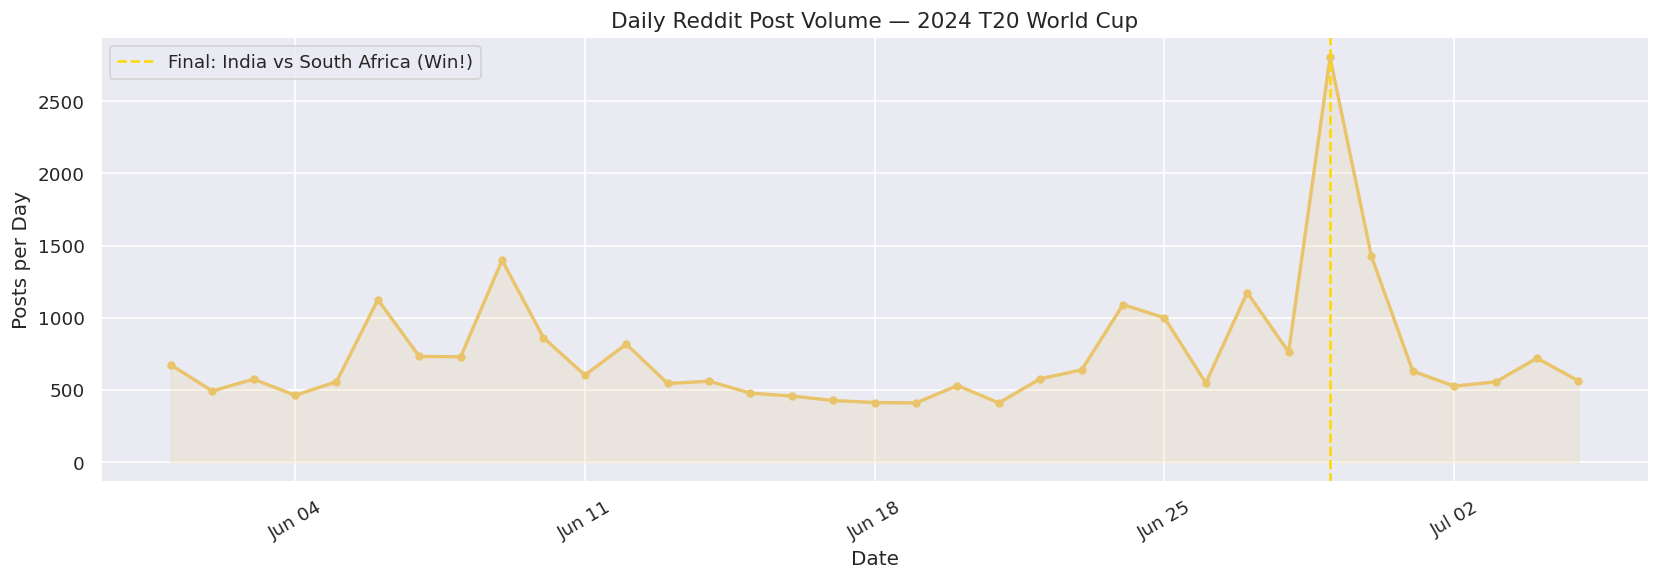

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_posts["date"], daily_posts["post_count"], color="#e9c46a", linewidth=2, marker="o", markersize=4)
ax.axvline(EVENT_DATES["t20wc2024_final"], color="gold", linestyle="--", linewidth=1.5, label="Final: India vs South Africa (Win!)")
ax.fill_between(daily_posts["date"], daily_posts["post_count"], alpha=0.15, color="#e9c46a")
ax.set_title("Daily Reddit Post Volume — 2024 T20 World Cup", fontsize=13)
ax.set_ylabel("Posts per Day")
ax.set_xlabel("Date")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
save_figure(fig, "04_daily_posts_t20wc2024.png")
plt.show()

### 8. Player mentions during T20 WC 2024

In [9]:
t20_subs = add_player_mentions(t20_subs, text_col="title")
t20_coms = add_player_mentions(t20_coms, text_col="body")

t20_mentions = t20_subs.agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).toPandas()
print("Player mentions during T20 WC 2024:")
print(t20_mentions)

Player mentions during T20 WC 2024:
   Dhoni  Kohli  Rohit
0    304   1030   1321


### 9. Player mentions by period

In [10]:
mentions_by_period = t20_subs.groupBy("event_period").agg(
    ssum(col("mentions_dhoni").cast("int")).alias("Dhoni"),
    ssum(col("mentions_kohli").cast("int")).alias("Kohli"),
    ssum(col("mentions_rohit").cast("int")).alias("Rohit"),
).toPandas()
print(mentions_by_period)
save_pandas_to_local(mentions_by_period, "04_t20wc2024_mentions_by_period.csv")

                event_period  Dhoni  Kohli  Rohit
0  t20wc2024_final_aftermath    126    476    512
1      t20wc2024_group_stage    178    554    809
Saved to results/tables/04_t20wc2024_mentions_by_period.csv


### 10. Grouped bar — mentions by period

Saved to results/figures/04_t20wc2024_mentions_by_period.png


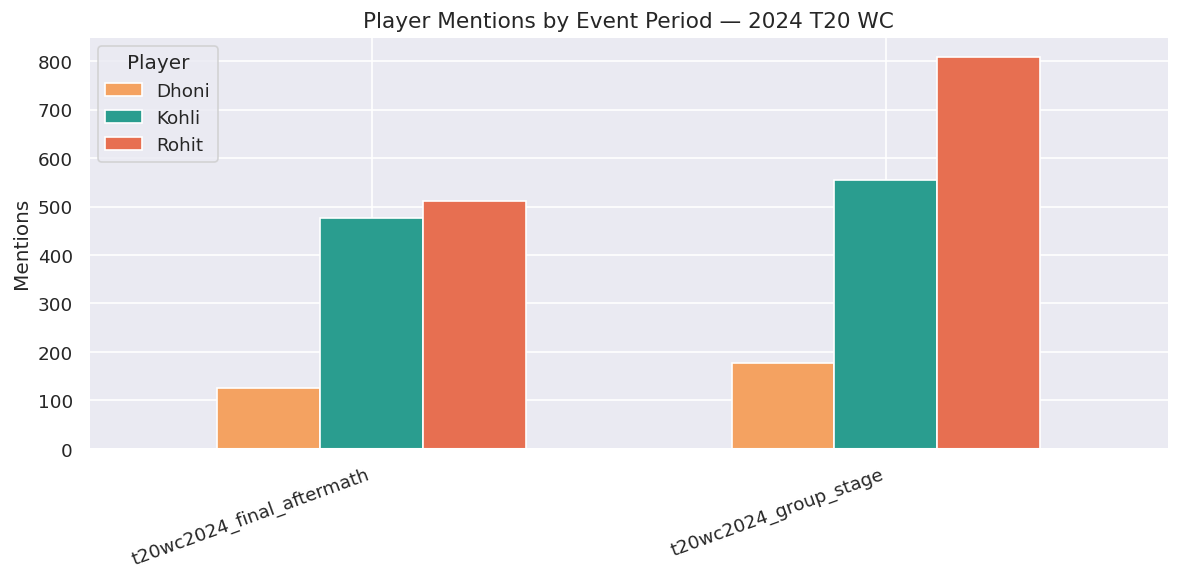

In [11]:
plot_df = mentions_by_period.set_index("event_period")[["Dhoni", "Kohli", "Rohit"]]
fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind="bar", ax=ax, color=["#f4a261", "#2a9d8f", "#e76f51"], edgecolor="white", width=0.6)
ax.set_title("Player Mentions by Event Period — 2024 T20 WC", fontsize=13)
ax.set_ylabel("Mentions")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Player")
plt.tight_layout()
save_figure(fig, "04_t20wc2024_mentions_by_period.png")
plt.show()

### 11. Top posts after the T20 final

In [12]:
top_aftermath = (
    t20_subs
    .filter(col("event_period") == "t20wc2024_final_aftermath")
    .select("title", "subreddit", "score", "num_comments", "created_dt")
    .orderBy(col("score").desc())
    .limit(10)
    .toPandas()
)
print(top_aftermath[["title", "subreddit", "score", "num_comments"]].to_string(index=False))
save_pandas_to_local(top_aftermath, "04_t20wc2024_top_aftermath_posts.csv")

                                                   title     subreddit  score  num_comments
    A scene for ages, an absolute cinema of a World Cup!  IndiaCricket  18710           291
             Rohit Sharma announces his T20I retirement        Cricket  13559           703
                   Surely will give goosebumps man!!!!!!  IndiaCricket  13206           335
           India are the champions of T20 World Cup 2024       Cricket  10893          1265
                                      Madness in Mumbai.       Cricket   9098           593
      Real Men Don't cry. Then I saw my heroes lik this.  IndiaCricket   8952           205
   Won't let the bus move, won't let the ambulance stop.  IndiaCricket   8801           170
 If it doesn’t give you chills, i don’t know what will!! MumbaiIndians   7114           193
ROHIT SHARMA RAW ECSTATIC MOMENTS AFTER WINNING THE CUP  MumbaiIndians   6494            97
                     Surya Kumar Yadav dancing in Delhi   IndiaCricket   6234   

### 12. Head-to-head: 2023 WC loss vs 2024 T20 win

In [13]:
wc2023_aftermath = subs.filter(col("event_period") == "wc2023_final_aftermath")
wc2023_stats = wc2023_aftermath.agg(
    count("*").alias("posts"),
    avg("score").alias("avg_score"),
    avg("num_comments").alias("avg_comments"),
).toPandas()
wc2023_stats["event"] = "2023 WC Final (Loss)"

t20_aftermath = subs.filter(col("event_period") == "t20wc2024_final_aftermath")
t20_stats = t20_aftermath.agg(
    count("*").alias("posts"),
    avg("score").alias("avg_score"),
    avg("num_comments").alias("avg_comments"),
).toPandas()
t20_stats["event"] = "2024 T20 Final (Win)"

comparison = pd.concat([wc2023_stats, t20_stats], ignore_index=True)
print(comparison)
save_pandas_to_local(comparison, "04_heartbreak_vs_redemption.csv")

   posts   avg_score  avg_comments                 event
0   5917   71.188778     15.992395  2023 WC Final (Loss)
1   7217  115.085077     18.772759  2024 T20 Final (Win)
Saved to results/tables/04_heartbreak_vs_redemption.csv


### 13. Bar chart — heartbreak vs redemption

/tmp/ipykernel_5058/1011025020.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["event"], rotation=15, ha="right")
/tmp/ipykernel_5058/1011025020.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["event"], rotation=15, ha="right")
/tmp/ipykernel_5058/1011025020.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison["event"], rotation=15, ha="right")


Saved to results/figures/04_heartbreak_vs_redemption.png


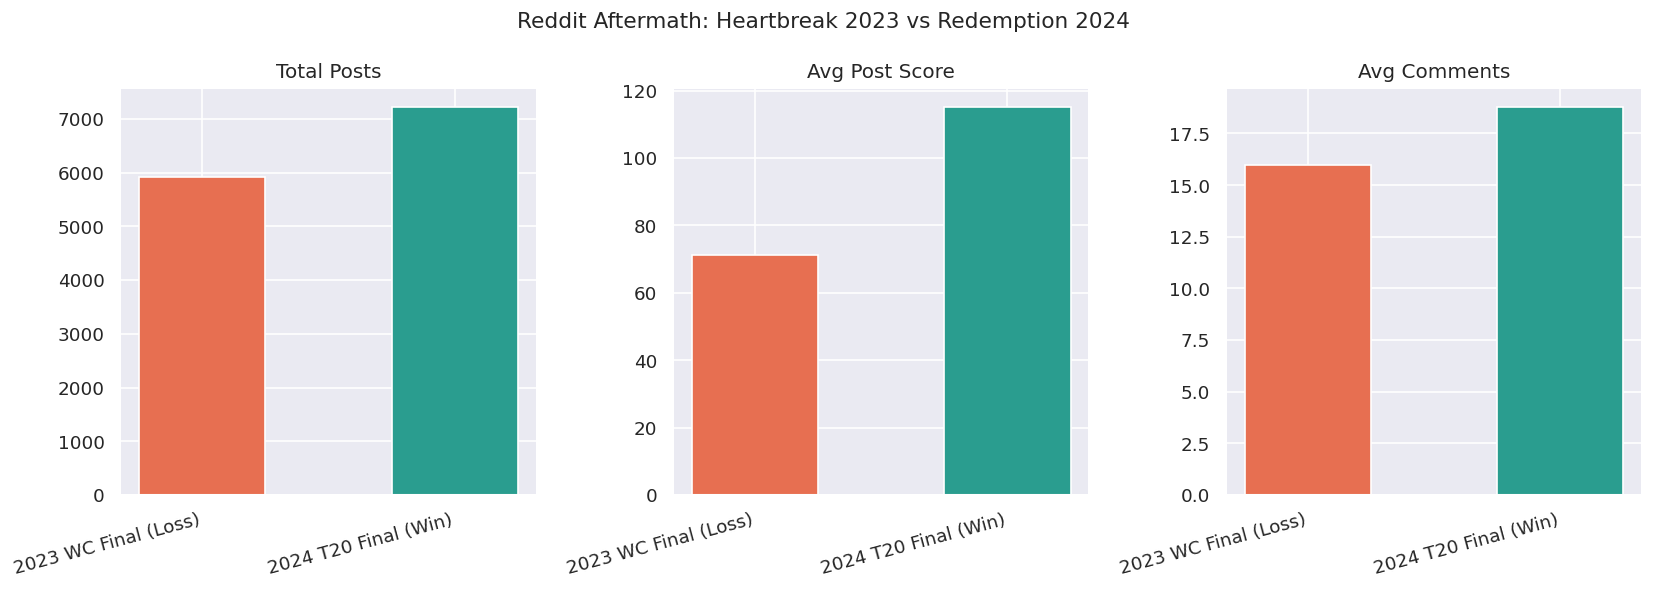

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
event_colors = ["#e76f51", "#2a9d8f"]
metrics = [("posts", "Total Posts"), ("avg_score", "Avg Post Score"), ("avg_comments", "Avg Comments")]

for ax, (metric, label) in zip(axes, metrics):
    ax.bar(comparison["event"], comparison[metric], color=event_colors, edgecolor="white", width=0.5)
    ax.set_title(label)
    ax.set_xticklabels(comparison["event"], rotation=15, ha="right")

plt.suptitle("Reddit Aftermath: Heartbreak 2023 vs Redemption 2024", fontsize=13)
plt.tight_layout()
save_figure(fig, "04_heartbreak_vs_redemption.png")
plt.show()

### 14. Stop Spark

In [15]:
spark.stop()